## Pendulum Mechancics

In [2]:
import sympy as sym
from sympy import symbols, solve, diff, Function, cos, sin, sqrt
sym.init_printing(use_latex=True)

In [3]:
l, c, m_shaft, m_rod, m_bob, r_shaft, t, g  = symbols('l c m_shaft m_rod m_bob r_shaft t g')

theta = Function('θ')(t)
x = Function('x')(t)


I_shaft = m_shaft/2*r_shaft**2
I_rod = m_rod/3*l**2

PE = -g * cos(theta) * (l/2*m_rod + l*m_bob)
PE = PE.simplify()
display(PE)

x_dot = diff(x,t)
theta_dot = diff(theta,t)
KE = m_rod/2*((x_dot + theta_dot*cos(theta)*l/2)**2 + (theta_dot*sin(theta)*l/2)**2) + m_bob/2*((x_dot + theta_dot*cos(theta)*l)**2 + (theta_dot*sin(theta)*l)**2) + (I_shaft + I_rod)/2*theta_dot**2
KE = KE.simplify()
display(KE)

In [4]:
L = sym.simplify(PE-KE)
display(L)

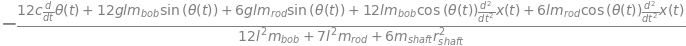

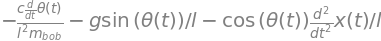

In [5]:
thdd_expr = solve(sym.Eq(diff(L,theta) - diff(diff(L,theta_dot), t).simplify(), -c*theta_dot), diff(theta, t, 2))[0].simplify()

display(thdd_expr)
display(thdd_expr.subs([(m_shaft,0),(m_rod,0)]).simplify())

In [6]:
y = sym.Matrix([[theta], [theta_dot], [x], [x_dot]])
f = sym.Matrix([[theta_dot], [thdd_expr], [x_dot], [sym.symbols('u')]])

display(y)
display(f.jacobian(y).subs(diff(x,t,2), 0))
display(diff(f, diff(x,t,2)))

⎡  θ(t)  ⎤
⎢        ⎥
⎢d       ⎥
⎢──(θ(t))⎥
⎢dt      ⎥
⎢        ⎥
⎢  x(t)  ⎥
⎢        ⎥
⎢d       ⎥
⎢──(x(t))⎥
⎣dt      ⎦

⎡                        0                                                 1   ↪
⎢                                                                              ↪
⎢-(12⋅g⋅l⋅m_bob⋅cos(θ(t)) + 6⋅g⋅l⋅m_rod⋅cos(θ(t)))                      -12⋅c  ↪
⎢──────────────────────────────────────────────────  ───────────────────────── ↪
⎢      2            2                          2         2            2        ↪
⎢  12⋅l ⋅m_bob + 7⋅l ⋅m_rod + 6⋅m_shaft⋅r_shaft      12⋅l ⋅m_bob + 7⋅l ⋅m_rod  ↪
⎢                                                                              ↪
⎢                        0                                                 0   ↪
⎢                                                                              ↪
⎣                        0                                                 0   ↪

↪                       0  0⎤
↪                           ⎥
↪                           ⎥
↪ ────────────────────  0  0⎥
↪                    2      ⎥
↪ + 6⋅m_shaft⋅r_shaft       ⎥
↪        

⎡                      0                       ⎤
⎢                                              ⎥
⎢-(12⋅l⋅m_bob⋅cos(θ(t)) + 6⋅l⋅m_rod⋅cos(θ(t))) ⎥
⎢──────────────────────────────────────────────⎥
⎢    2            2                          2 ⎥
⎢12⋅l ⋅m_bob + 7⋅l ⋅m_rod + 6⋅m_shaft⋅r_shaft  ⎥
⎢                                              ⎥
⎢                      0                       ⎥
⎢                                              ⎥
⎣                      0                       ⎦

### Total energy for control mode

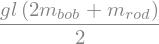

In [12]:
E_max = PE.subs(theta, sym.pi)
display(E_max)


E = (KE+PE).simplify()
display(E)

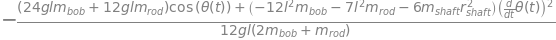

In [19]:
E_norm = (E.subs(x_dot, 0)/E_max).simplify()
display(E_norm.factor(sym.cos(theta), theta_dot))

